<a href="https://colab.research.google.com/github/NavSaxena/california-housing-prediction/blob/main/housing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Shape:
(20640, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null

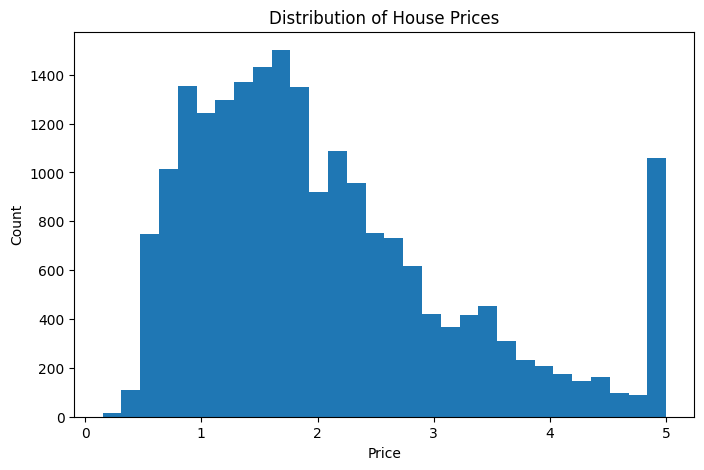


Correlation with Price:
Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


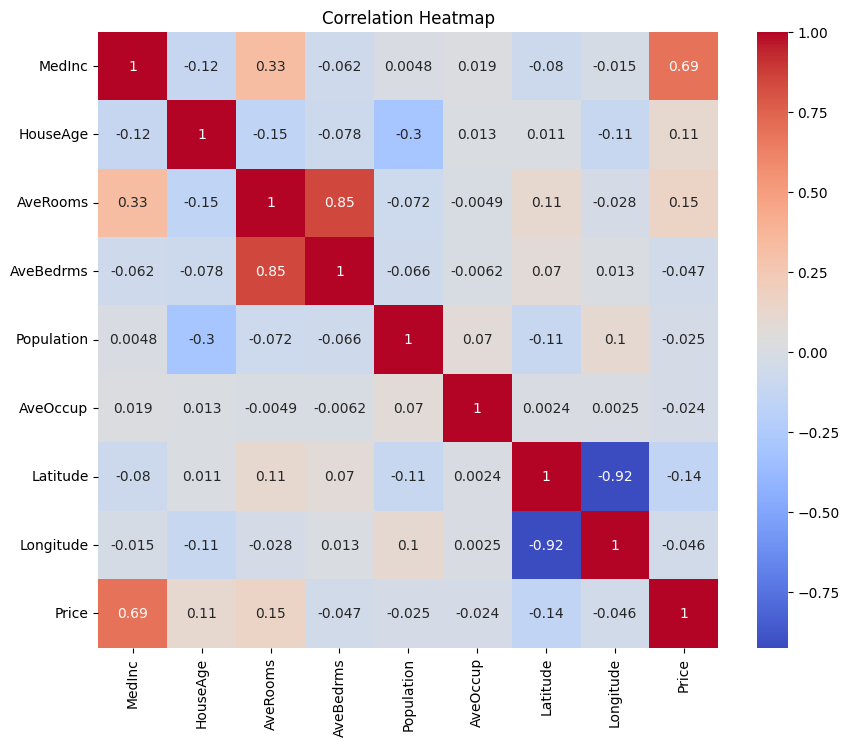


LINEAR REGRESSION
MAE : 0.5342218724337039
MSE : 0.9876108511267103
RMSE: 0.9937861194073453
R²  : 0.2612006670839714

Pipeline Linear R²:
0.2612006670839667
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best Random Forest CV Score:
0.7406651808947876

Tuned Random Forest R²:
0.7717351670673819
Tuned Random Forest RMSE:
0.5523942932200491
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Best XGBoost CV Score:
0.7881110097060531

Tuned XGBoost R²:
0.8149023145326826
Tuned XGBoost RMSE:
0.4974279374797544

MODEL COMPARISON
                 Model        R2      RMSE
2        Tuned XGBoost  0.814902  0.497428
1  Tuned Random Forest  0.771735  0.552394
0    Linear Regression  0.261201  0.993786

Final Model R²:
0.8149023145326826

Sample House Features:
       MedInc  HouseAge  AveR

In [9]:
#========================================================= PROJECT: California Housing Price Prediction ==============================================================#

#IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#LOADING DATA
housing = fetch_california_housing()
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)
df["Price"] = housing.target
print(df.head())

#BASIC DATA INSPECTION
print("\nShape:")
print(df.shape)
print("\nInfo:")
df.info()
print("\nDescription:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:")
print(df.duplicated().sum())

#TARGET VARIABLE ANALYSIS
print("\nPrice Description:")
print(df["Price"].describe())
plt.figure(figsize=(8, 5))
plt.hist(df["Price"],bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Distribution of House Prices")
plt.show()

#CORRELATION ANALYSIS
correlation = df.corr()
print("\nCorrelation with Price:")
print(correlation["Price"].sort_values(ascending=False))
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#FEATURE AND TARGET
X = df.drop("Price",axis=1)
y = df["Price"]

#SPLITTING TRAINING AND TESTING DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#LINEAR REGRESSION MODEL
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test,linear_pred)
linear_mse = mean_squared_error(y_test,linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test,linear_pred)
print("\nLINEAR REGRESSION")
print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

linear_pipe= Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_pipe.fit(X_train,y_train)
pipe_predictions = linear_pipe.predict(X_test)
pipe_r2 = r2_score(y_test,pipe_predictions)
print("\nPipeline Linear R²:")
print(pipe_r2)

#RANDOM FOREST MODEL
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [10,20,None],
    "min_samples_split": [2,5]
}
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train,y_train)
print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)
print("\nBest Random Forest CV Score:")
print(rf_grid.best_score_)

best_rf = rf_grid.best_estimator_
best_rf_pred = best_rf.predict(X_test)
best_rf_r2 = r2_score(y_test,best_rf_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test,best_rf_pred))
print("\nTuned Random Forest R²:")
print(best_rf_r2)
print("Tuned Random Forest RMSE:")
print(best_rf_rmse)

#XGBOOST MODEL
xgb_model = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [100,200],
    "learning_rate": [0.05,0.1],
    "max_depth": [3,5]
}
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train,y_train)
print("\nBest XGBoost Parameters:")
print(xgb_grid.best_params_)
print("\nBest XGBoost CV Score:")
print(xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)
best_xgb_r2 = r2_score(y_test,best_xgb_pred)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test,best_xgb_pred))
print("\nTuned XGBoost R²:")
print(best_xgb_r2)
print("Tuned XGBoost RMSE:")
print(best_xgb_rmse)

#COMPARISION BETWEEN ALL THE MODELS
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "R2": [
        linear_r2,
        best_rf_r2,
        best_xgb_r2
    ],
    "RMSE": [
        linear_rmse,
        best_rf_rmse,
        best_xgb_rmse
    ]
})
results = results.sort_values(
    by="R2",
    ascending=False
)
print("\nMODEL COMPARISON")
print(results)

#FINAL MODEL
final_model = best_xgb
final_pred = final_model.predict(X_test)
print("\nFinal Model R²:")
print(r2_score(y_test,final_pred))

#SAMPLE PREDICTION
sample_house = X_test.iloc[[0]]
print("\nSample House Features:")
print(sample_house)
predicted_price = final_model.predict(sample_house)
actual_price = y_test.iloc[0]
print("\nPredicted Price:")
print(predicted_price[0])
print("\nActual Price:")
print(actual_price)